# Zelle 1: Initialisierung und Importe
In dieser Zelle werden alle benoetigten Bibliotheken geladen und die Pfade konfiguriert.

In [62]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.stats import kurtosis
from dataframe_manager import DataFrameManager
from stft_processor import calculate_stft

data_path = '../data'
if not os.path.exists(data_path):
    print(f"Fehler: Datenordner nicht gefunden.")

# Zelle 2: Daten laden und Multi-Scale Parameter Optimierung
Diese Zelle lädt die Signaldaten und bestimmt automatisch die optimalen STFT-Parameter für zwei verschiedene Analyse-Foki:
1. **Kurzes Fenster (Short Window):** Optimiert für eine hohe zeitliche Auflösung, um impulsive Ereignisse (z.B. Zahnschäden, Stöße) zeitlich scharf zu lokalisieren.
2. **Langes Fenster (Long Window):** Optimiert fuer eine hohe Frequenzauflösung, um stationäre spektrale Merkmale (z.B. Seitenbänder, Harmonische) voneinander zu trennen.

### Mathematische Grundlagen und Konzepte:

**1. Kurzzeit-Fourier-Transformation (STFT):**
Im Gegensatz zur klassischen FFT, die das gesamte Signal in den Frequenzbereich transformiert und dabei alle Zeitinformationen verliert, verwendet die STFT ein **gleitendes Fenster** $w[n]$.
$$X(m, \omega) = \sum_{n=-\infty}^{\infty} x[n] w[n - m] e^{-j \omega n}$$
Das Signal wird in kleine Abschnitte unterteilt, die jeweils einzeln transformiert werden. So entsteht ein Abbild der Frequenzen über dem Zeitverlauf (Spektrogramm). Ein kurzes Fenster sieht zwar zeitlich scharf, verschmiert aber die Frequenzen (Unschärferelation).

**2. Energieprofil ($E[m]$):**
Das Energieprofil stellt die summierte Intensität aller Frequenzanteile pro Zeitpunkt $m$ dar:
$$E[m] = \sum_{k=0}^{K} |X(m, f_k)|$$
Es wandelt das komplexe Spektrogramm in einen eindimensionalen Zeitverlauf um, der die "momentane Energie" des Getriebes beschreibt. Unregelmässigkeiten im Zahneingriff äussern sich hier als periodische Peaks.

**3. Diagnose-Kontrast (Clarity):**
Die Metrik findet die Parameter ($window-length$, $function$, $overlap$), die den energetischen Unterschied zwischen Zahnrad Z01 und Z05 maximieren. 
$$Clarity = |P(E_{Z01} > E_{Z05}) - 0.5| \cdot 200$$
Wir berechnen die Wahrscheinlichkeit $P$, dass die Energie von Z01 groeßer ist als die von Z05. 
- **0% Clarity:** Die Zahnräder sind energetisch identisch ($P=0.5$).
- **100% Clarity:** Die Zahnräder sind vollständig unterscheidbar ($P=1$ oder $P=0$).

**4. Fensterfunktionen:**
Wir untersuchen verschiedene Fenstertypen, um den optimalen Kompromiss zwischen Frequenzauflösung und Leckeffekt (Spectral Leakage) zu finden. Standardmässig werden Fenster wie **Hann** bevorzugt, da sie Geisterfrequenzen minimieren. Ein **Boxcar** (Rechteckfenster) wird nur gewaehlt, wenn es eine deutlich hoehere Clarity ($>5\%$) liefert (nur in unserer Berechnung).

In [66]:
manager = DataFrameManager(data_dir=data_path)
manager.load_signals()
df = manager.get_dataframe()
print(f"Erfolgreich {len(df)} Signale geladen.")

def find_best_windows(df, r_id='00000'):
    # Suchbereiche fuer beide Skalen
    nperseg_short = range(128, 513, 32)      
    nperseg_long = range(1024, 4097, 256)    
    overlap_ratios = [0.5, 0.75, 0.9]        
    windows = ["hann", "hamming", "blackman", "boxcar"]
    
    def optimize_scale(n_range):
        results = []
        for win in windows:
            for nps in n_range:
                for ratio in overlap_ratios:
                    nov = int(nps * ratio)
                    scale_contrast = []
                    for s_id in ['Ch1', 'Ch2']:
                        z01_q = df[(df['spec']=='Z01') & (df['sID'] == s_id) & (df['rID'] == r_id)]
                        z05_q = df[(df['spec']=='Z05') & (df['sID'] == s_id) & (df['rID'] == r_id)]
                        if z01_q.empty or z05_q.empty: continue
                        f, _, s1 = calculate_stft(z01_q.iloc[0]['sig'], z01_q.iloc[0]['fs'], nperseg=nps, noverlap=nov, window=win)
                        _, _, s5 = calculate_stft(z05_q.iloc[0]['sig'], z05_q.iloc[0]['fs'], nperseg=nps, noverlap=nov, window=win)
                        e1, e5 = np.sum(np.abs(s1), axis=0), np.sum(np.abs(s5), axis=0)
                        prob = np.mean(e1 > e5)
                        contrast = abs(prob - 0.5) * 200
                        scale_contrast.append(contrast)
                    if scale_contrast:
                        results.append({'nperseg': nps, 'window': win, 'noverlap': nov, 'clarity': np.mean(scale_contrast)})
        
        res_df = pd.DataFrame(results)
        # Auswahl-Logik: Bevorzuge Nicht-Boxcar, auBer Boxcar ist > 5% besser
        non_boxcar = res_df[res_df['window'] != 'boxcar'].sort_values('clarity', ascending=False)
        boxcar_only = res_df[res_df['window'] == 'boxcar'].sort_values('clarity', ascending=False)
        
        if not boxcar_only.empty and not non_boxcar.empty:
            if boxcar_only.iloc[0]['clarity'] > non_boxcar.iloc[0]['clarity'] + 5.0:
                return boxcar_only.iloc[0]
        return non_boxcar.iloc[0] if not non_boxcar.empty else boxcar_only.iloc[0]

    print("Suche optimale Parameter fuer Zeit-Aufloesung (Short Window)...")
    best_short = optimize_scale(nperseg_short)
    print("Suche optimale Parameter fuer Frequenz-Aufloesung (Long Window)...")
    best_long = optimize_scale(nperseg_long)
    return best_short, best_long

OPT_SHORT, OPT_LONG = find_best_windows(df)
print(f"\nErgebnis der Optimierung:")
print(f"Best Short: window-length={OPT_SHORT['nperseg']}, function={OPT_SHORT['window']}, overlap={OPT_SHORT['noverlap']}, Clarity={OPT_SHORT['clarity']:.2f}%")
print(f"Best Long:  window-length={OPT_LONG['nperseg']}, function={OPT_LONG['window']}, overlap={OPT_LONG['noverlap']}, Clarity={OPT_LONG['clarity']:.2f}%")

Y_FREQ_MAX, X_TIME_MAX = 200000, 0.1

Erfolgreich 12 Signale geladen.
Suche optimale Parameter fuer Zeit-Aufloesung (Short Window)...
Suche optimale Parameter fuer Frequenz-Aufloesung (Long Window)...

Ergebnis der Optimierung:
Best Short: window-length=512, function=hann, overlap=460, Clarity=98.06%
Best Long:  window-length=3584, function=hann, overlap=3225, Clarity=98.63%


# Zelle 3: Stabilitaets-Analyse der Testlaeufe (rID 00000 vs. 00001)
Berechnung der mathematischen Stabilitaet (RMS, Peak-to-Peak) zwischen den Testlaeufen rID 00000 und 00001 ueber beide Skalen (Short & Long).

In [64]:
def calc_stability(df, rids=['00000', '00001']):
    stats = []
    for spec in ['Z01', 'Z05']:
        for s_id in ['Ch1', 'Ch2']:
            row_vals = {}
            for r_id in rids:
                q = df[(df['spec']==spec) & (df['sID']==s_id) & (df['rID']==r_id)]
                if q.empty: continue
                sig = q.iloc[0]['sig']
                row_vals[f"RMS_{r_id}"] = np.sqrt(np.mean(sig**2))
                row_vals[f"PTP_{r_id}"] = np.ptp(sig)
            if f"RMS_{rids[0]}" in row_vals and f"RMS_{rids[1]}" in row_vals:
                diff = abs(row_vals[f"RMS_{rids[0]}"] - row_vals[f"RMS_{rids[1]}"]) / row_vals[f"RMS_{rids[0]}"] * 100
                stats.append({'Spec': spec, 'Sensor': s_id, 'Diff_Perc': diff, 
                              'PTP0': row_vals[f"PTP_{rids[0]}"], 'PTP1': row_vals[f"PTP_{rids[1]}"]})
    return pd.DataFrame(stats)

STAB_RESULTS = calc_stability(df)
print("Stabilitaet der Testlaeufe erfolgreich berechnet.")
display(STAB_RESULTS)

Stabilitaet der Testlaeufe erfolgreich berechnet.


,Spec,Sensor,Diff_Perc,PTP0,PTP1
0,Z01,Ch1,6.011886,0.516327,0.539276
1,Z01,Ch2,7.685738,0.779144,0.815765
2,Z05,Ch1,1.478378,0.411285,0.414703
3,Z05,Ch2,2.264393,0.763519,0.769867


# Zelle 4: Qualitaets-Entscheidung und Multi-Scale Vergleichsplots
Diese Zelle bewertet die Stabilitaet der Messungen und stellt Z01 und Z05 in einem hochaufloesenden Vergleich gegenueber.

--- Qualitaets-Bewertung der Testlaeufe ---
Z01 / Ch1: ABWEICHUNG (Abweichung: 6.01%) -> Nutze rID 00000
Z01 / Ch2: ABWEICHUNG (Abweichung: 7.69%) -> Nutze rID 00000
Z05 / Ch1: STABIL (Abweichung: 1.48%) -> Nutze rID 00000
Z05 / Ch2: STABIL (Abweichung: 2.26%) -> Nutze rID 00000


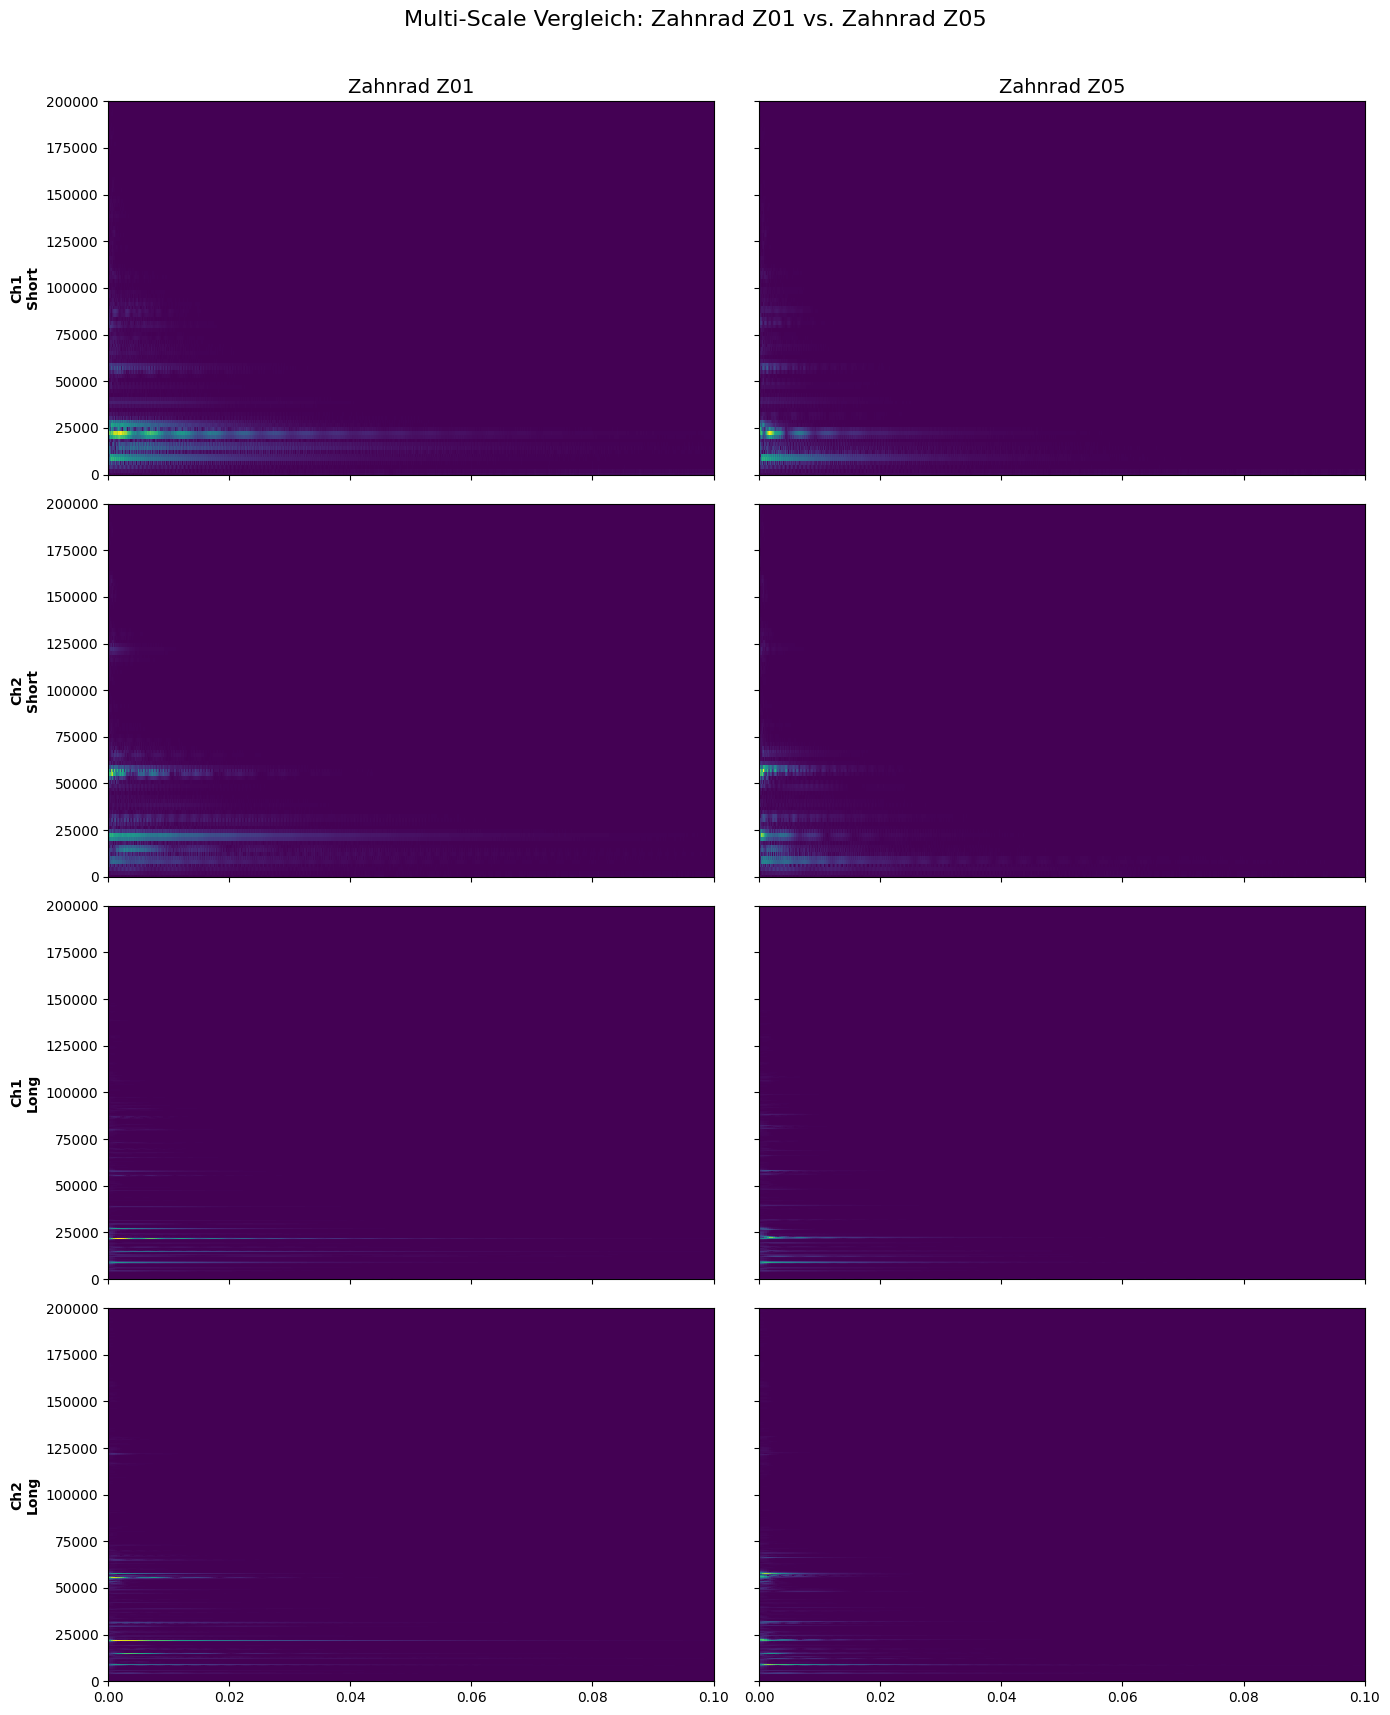

In [65]:
def decide_and_plot(df, s_res):
    print("--- Qualitaets-Bewertung der Testlaeufe ---")
    for i in range(len(s_res)):
        s = s_res.iloc[i]
        status = "STABIL" if s['Diff_Perc'] < 5.0 else "ABWEICHUNG"
        print(f"{s['Spec']} / {s['Sensor']}: {status} (Abweichung: {s['Diff_Perc']:.2f}%) -> Nutze rID 00000")

    fig, axes = plt.subplots(4, 2, figsize=(14, 18), sharex=True, sharey='row')
    fig.suptitle("Multi-Scale Vergleich: Zahnrad Z01 vs. Zahnrad Z05", fontsize=16)
    configs = [('Ch1', OPT_SHORT, "Short"), ('Ch2', OPT_SHORT, "Short"), ('Ch1', OPT_LONG, "Long"), ('Ch2', OPT_LONG, "Long")]
    for row, (s_id, opt, label) in enumerate(configs):
        for col, spec in enumerate(['Z01', 'Z05']):
            data = df[(df['spec']==spec) & (df['sID']==s_id) & (df['rID']=='00000')].iloc[0]
            f, t, Zxx = calculate_stft(data['sig'], data['fs'], nperseg=opt['nperseg'], noverlap=opt['noverlap'], window=opt['window'])
            axes[row, col].pcolormesh(t, f, np.abs(Zxx), shading='nearest')
            axes[row, col].set_ylim(0, Y_FREQ_MAX); axes[row, col].set_xlim(0, X_TIME_MAX)
            if col == 0: axes[row, col].set_ylabel(f"{s_id}\n{label}", fontweight='bold')
            if row == 0: axes[row, col].set_title(f"Zahnrad {spec}", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.97]); plt.show()

decide_and_plot(df, STAB_RESULTS)

# Zelle 5: Statistische Amplitudenverteilung (Histogramm und Kurtosis)
Diese Zelle vergleicht die Wahrscheinlichkeitsdichtefunktion der Signale von Z01 und Z05 ueber den gesamten Aufnahmezeitraum. Da diese Analyse auf dem Zeitbereichssignal basiert, ist sie unabhaengig von der STFT-Fensterlaenge, liefert jedoch die statistische Basis fuer die Wahl zwischen Short- und Long-Window.

### Visuelle Interpretation der Kurtosis:
1. **Kurtosis $\approx$ 3 (Normalverteilung):** Das Histogramm zeigt eine klassische Glockenkurve. Auf der **logarithmischen y-Achse** sieht man, dass die Amplituden zu den Raendern hin gleichmaeBig und steil abfallen. Es gibt keine ungewoehnlich hohen Spitzen in den Randbereichen.
2. **Kurtosis > 3 (Leptokurtisch):** Das Histogramm hat eine schaerfere Spitze in der Mitte und deutlich ausgepraegtere 'Fat Tails'. Auf der log-Skala erkennt man dies daran, dass die Auslaeufer (hohe Amplituden) flacher abfallen und weiter nach auBen reichen. Dies ist ein Indiz fuer impulsive Stoesse (Defekte).
3. **Skalierung:** Die log-y-Achse ist entscheidend, da sie die seltenen, aber physikalisch wichtigen Stoerimpulse im Randbereich sichtbar macht, die in einer linearen Darstellung untergehen wuerden.

In [ ]:
def plot_histograms_refined(df, r_id='00000'):
    sensors = ['Ch1', 'Ch2']
    fig, axes = plt.subplots(len(sensors), 1, figsize=(12, 10))
    fig.suptitle("Vergleich der Amplitudenverteilung (Log-Skalierung)", fontsize=14)
    for i, s_id in enumerate(sensors):
        sig1 = df[(df['spec']=='Z01') & (df['sID']==s_id) & (df['rID']==r_id)].iloc[0]['sig']
        sig5 = df[(df['spec']=='Z05') & (df['sID']==s_id) & (df['rID']==r_id)].iloc[0]['sig']
        axes[i].hist(sig1, bins=150, alpha=0.6, label='Z01', density=True, color='blue', histtype='stepfilled')
        axes[i].hist(sig5, bins=150, alpha=0.4, label='Z05', density=True, color='red', histtype='stepfilled')
        axes[i].set_yscale('log')
        k1, k5 = kurtosis(sig1, fisher=False), kurtosis(sig5, fisher=False)
        axes[i].set_title(f"Sensor {s_id} | Kurtosis: Z01={k1:.2f}, Z05={k5:.2f}")
        axes[i].legend(); axes[i].set_xlabel("Amplitude"); axes[i].set_ylabel("Log-Dichte")
    plt.tight_layout(); plt.show()

plot_histograms_refined(df)

# Zelle 6: Spektrale Leistungsdichte (PSD - Power Spectral Density)
Diese Zelle berechnet die Energieverteilung ueber das Frequenzspektrum unter Verwendung des **Long Window (OPT_LONG)**. Ein laengeres Fenster bietet eine hoehere Frequenzaufloesung, was fuer die Identifikation spezifischer Schadensfrequenzen unerlaesslich ist.

### Methodik und worauf zu achten ist:
1. **Verwendetes Fenster:** Es wird das **Long-Best Fenster** genutzt, um eine maximale Trennschaerfe zwischen benachbarten Frequenzlinien zu erreichen.
2. **Energie-Niveau:** Pruefen Sie, ob ein Zahnrad in bestimmten Bereichen (z.B. bei der Zahneingriffsfrequenz oder deren Harmonischen) ein signifikant hoeheres Energieniveau aufweist.
3. **Seitenbaender:** Achten Sie auf symmetrische 'Peaks' um eine Hauptfrequenz herum. Solche Seitenbaender sind ein klassisches Indiz fuer Modulationen, die durch lokale Defekte (z.B. Risse) verursacht werden.

In [ ]:
def plot_psd_refined(df, r_id='00000'):
    sensors = ['Ch1', 'Ch2']
    fig, axes = plt.subplots(len(sensors), 1, figsize=(12, 10))
    for i, s_id in enumerate(sensors):
        d1 = df[(df['spec']=='Z01') & (df['sID']==s_id) & (df['rID']==r_id)].iloc[0]
        d5 = df[(df['spec']=='Z05') & (df['sID']==s_id) & (df['rID']==r_id)].iloc[0]
        f1, p1 = signal.welch(d1['sig'], d1['fs'], nperseg=OPT_LONG['nperseg'])
        f5, p5 = signal.welch(d5['sig'], d5['fs'], nperseg=OPT_LONG['nperseg'])
        axes[i].semilogy(f1, p1, label='Z01', color='blue', alpha=0.8)
        axes[i].semilogy(f5, p5, label='Z05', color='red', alpha=0.6)
        axes[i].set_xlim(0, Y_FREQ_MAX); axes[i].set_title(f"PSD Vergleich - Sensor {s_id}")
        axes[i].legend(); axes[i].set_ylabel("Leistung/Hz (log)")
    plt.tight_layout(); plt.show()

plot_psd_refined(df)

# Zelle 7: Autokorrelations-Analyse
In dieser Zelle untersuchen wir die Periodizitaet der Signale. Die Autokorrelation vergleicht das Signal mit einer zeitlich verschobenen Kopie seiner selbst. Um transierte (kurzzeitige) Unregelmaessigkeiten im Zahneingriff sichtbar zu machen, korreliert diese Analyse eng mit der Dynamik des **Short Windows (OPT_SHORT)**.

### Methodik und worauf zu achten ist:
1. **Peak-Struktur:** Die Hauptpeaks zeigen die dominante Periode des Zahneingriffs. Bei einem intakten Zahnrad sind diese Peaks gleichmaeBig und stabil.
2. **Signalzerfall:** Achten Sie darauf, wie schnell die Korrelation bei groesseren Zeitverschiebungen (Lags) abnimmt. Ein schnellerer oder unruhiger Zerfall bei einem der Zahnraeder deutet auf stoerende impulsive Ereignisse hin, die die Regelmaessigkeit brechen.

In [ ]:
def plot_autocorr_refined(df, r_id='00000'):
    sensors = ['Ch1', 'Ch2']
    fig, axes = plt.subplots(len(sensors), 1, figsize=(12, 10))
    for i, s_id in enumerate(sensors):
        sig1 = df[(df['spec']=='Z01') & (df['sID']==s_id) & (df['rID']==r_id)].iloc[0]['sig'][:8000]
        sig5 = df[(df['spec']=='Z05') & (df['sID']==s_id) & (df['rID']==r_id)].iloc[0]['sig'][:8000]
        def get_acorr(s):
            c = signal.correlate(s - np.mean(s), s - np.mean(s), mode='same')
            return c / np.max(c)
        corr1, corr5 = get_acorr(sig1), get_acorr(sig5)
        lags = np.arange(-len(sig1)//2, len(sig1)//2)
        axes[i].plot(lags, corr1, label='Z01', color='blue', alpha=0.7)
        axes[i].plot(lags, corr5, label='Z05', color='red', alpha=0.5)
        axes[i].set_xlim(0, 2000); axes[i].set_title(f"Autokorrelation (Ausschnitt) - Sensor {s_id}")
        axes[i].legend(); axes[i].set_xlabel("Lag (Samples)")
    plt.tight_layout(); plt.show()

plot_autocorr_refined(df)